# **Introduction**  

This notebook introduces key concepts in machine learning, starting with the distinction between **supervised** and **unsupervised learning**. Understanding this difference is essential before diving deeper into specific techniques.  

The focus then shifts to **Regression**, one of the most fundamental methods in supervised learning. Through this notebook, you will:  

- Explore the differences between **supervised** and **unsupervised learning** and their typical applications.  
- Build an understanding of **Linear Regression** and how it models relationships between variables.  
- Learn about the **cost function** as a measure of prediction accuracy.  
- Apply **gradient descent** to optimize regression models effectively.  

By the end, you will have a solid foundation in regression analysis and the role it plays in supervised machine learning.  


# **Resources**

Supervised and Unsupervised Learning:
* [Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/supervised-unsupervised-learning/)
* [Video explanation](https://www.youtube.com/watch?v=W01tIRP_Rqs)

Regression:
* [Geeksforgeeks](https://www.geeksforgeeks.org/machine-learning/regression-in-machine-learning/)
* [Video course](https://www.youtube.com/watch?v=4b4MUYve_U8)
* [An introduction to statistical learning](https://www.statlearning.com/) (Chapter 3 - Linear Regression)

# **Supervised and Unsupervised Learning**

Before diving into regression, it is important to understand the broader categories of machine learning approaches: **supervised** and **unsupervised learning**.  

In this section, we will:  

- Compare supervised and unsupervised learning approaches.  
- Highlight the types of problems each method is best suited for.  
- Understand why regression belongs to the supervised learning family.  

This understanding will give us the context needed to see how regression fits into the larger picture of machine learning techniques.  


<img src="https://i.imgur.com/Ky3f3B5.png" width="1100">

Machine learning methods can generally be grouped into two broad categories: **supervised** and **unsupervised learning**. Understanding the difference between these two approaches helps clarify where regression fits within the field.  

### Supervised Learning  
In supervised learning, the model is trained on a **dataset that includes both the input features and the correct output (labels)**. **The goal** is to learn a mapping from inputs to outputs so that the model can make accurate predictions on new, unseen data.  

Common supervised learning tasks include:  
- **Regression**: predicting continuous values (e.g., house prices, sales forecasting).  
- **Classification**: predicting categories (e.g., spam vs. not spam emails, disease detection).  

Supervised learning is like practicing for a test with an answer key — the model learns by comparing its predictions with the known correct answers.  

### Unsupervised Learning  
In unsupervised learning, the **dataset does not contain labeled outputs**. Instead, **the goal** is to uncover hidden structures, patterns, or groupings within the data.  

Common unsupervised learning tasks include:  
- **Clustering**: grouping similar data points together (e.g., customer segmentation).  
- **Dimensionality Reduction**: simplifying data by reducing the number of variables while preserving important information (e.g., PCA for visualization).  

Unsupervised learning is like exploring without a guide — the model must make sense of the data on its own.  

### Where Regression Fits  
Regression is a type of **supervised learning**, since the model is trained with labeled data (input features and their corresponding continuous outputs). It is one of the foundational techniques for making predictions in machine learning.  


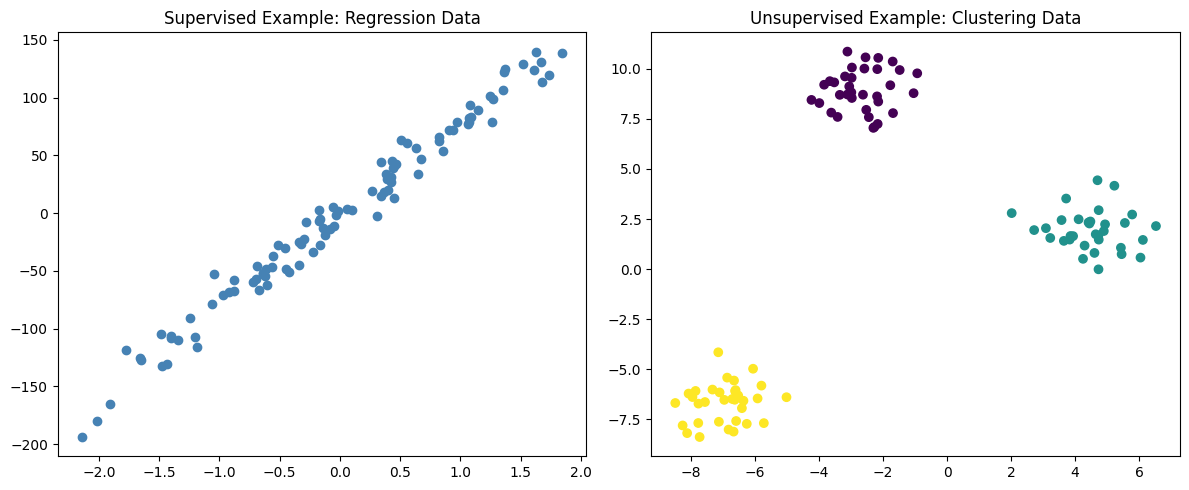

In [ ]:
# Example: Generating synthetic data
from sklearn.datasets import make_regression, make_blobs
import matplotlib.pyplot as plt

# Supervised data (regression)
X_reg, y_reg = make_regression(n_samples=100, n_features=1, noise=10)

# Unsupervised data (clustering)
X_clust, y_clust = make_blobs(n_samples=100, centers=3, random_state=42)

# Create subplots (1 row, 2 columns)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot supervised regression data
axes[0].scatter(X_reg, y_reg, color="steelblue")
axes[0].set_title("Supervised Example: Regression Data")

# Plot unsupervised clustering data
axes[1].scatter(X_clust[:, 0], X_clust[:, 1], c=y_clust, cmap="viridis")
axes[1].set_title("Unsupervised Example: Clustering Data")

plt.tight_layout()
plt.show()

### Bonus: Beyond Supervised and Unsupervised Learning  

While supervised and unsupervised learning are the most common categories, there are two additional approaches worth mentioning: **semi-supervised** and **self-supervised learning**.  

#### Semi-Supervised Learning  
Semi-supervised learning is a hybrid approach that uses a small amount of labeled data along with a large amount of unlabeled data.  
- The labeled data provides guidance, while the unlabeled data helps the model generalize better.  
- This is especially useful when labeling data is expensive or time-consuming (e.g., medical images where only a few are labeled by experts).  

Think of it as learning with a partial answer key: you get some correct answers, but you also have to figure out the rest from patterns in the data.  

#### Self-Supervised Learning  
Self-supervised learning is a newer approach that has become very influential, especially in natural language processing (NLP) and computer vision.  
- The idea is to create **labels automatically from the data itself** by designing a *pretext task*.  
- For example, predicting missing words in a sentence (like in large language models) or predicting missing parts of an image.  
- Once trained on this self-generated task, the model can be fine-tuned for real downstream tasks with much less labeled data.  

You can think of this as the model setting its own practice problems to learn from, before tackling the actual test.  


**Summary of Learning Types:**  
- **Supervised**: Inputs → Outputs (with labels)  
- **Unsupervised**: Inputs → Patterns/Groups (no labels)  
- **Semi-Supervised**: Mostly unlabeled data + some labeled examples  
- **Self-Supervised**: Labels are created automatically from the data itself  


# **Linear Regression**

## What is Linear Reggression?
Linear Regression models the relationship between a **dependent variable** $y$ and an **independent variable** $x$.

In 2D, the hypothesis (model) is:
$$
y = m x + b
$$

Where:
- $x$ = independent variable (feature)
- $y$ = dependent variable (target)
- $m$ = slope of the line
- $b$ = intercept (value when $x=0$)

**Goal:** predict $y$ from $x$ as accurately as possible.


## How can we measure how good the line is?

We use a **cost function** to quantify prediction error. A common choice is **Mean Squared Error (MSE)**:
$$
J(m,b) = \frac{1}{2n} \sum_{i=1}^{n}\Big(y^{(i)} - (m\,x^{(i)} + b)\Big)^2
$$

Where:
- $n$ = number of data points
- $x^{(i)}, y^{(i)}$ = the $i$-th input/output pair
- $m\,x^{(i)} + b$ = prediction for $x^{(i)}$

**Interpretation:** smaller $J(m,b)$ means a better fit.




## How can we find the best line?

We minimize $J(m,b)$ with **gradient descent**, updating $m$ and $b$ iteratively:
$$
m \leftarrow m - \alpha \frac{\partial J}{\partial m}, \qquad
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

With MSE, the gradients are:
$$
\frac{\partial J}{\partial m} = -\frac{1}{n}\sum_{i=1}^{n} x^{(i)}\Big(y^{(i)} - (m\,x^{(i)} + b)\Big)
$$

$$
\frac{\partial J}{\partial b} = -\frac{1}{n}\sum_{i=1}^{n} \Big(y^{(i)} - (m\,x^{(i)} + b)\Big)
$$

Notes:
- $\alpha > 0$ is the **learning rate** (step size).
- Repeat updates until convergence (e.g., changes in $J$ become very small).

## How do we interpret the results?

* Slope $m$ → rate at which $y$ changes with $x$
* Intercept $b$ → value of $y$ when $x=0$
* Cost function → smaller = better fit

## How do we implement it in Python?

Final slope (m): 3.10, Intercept (b): 6.15


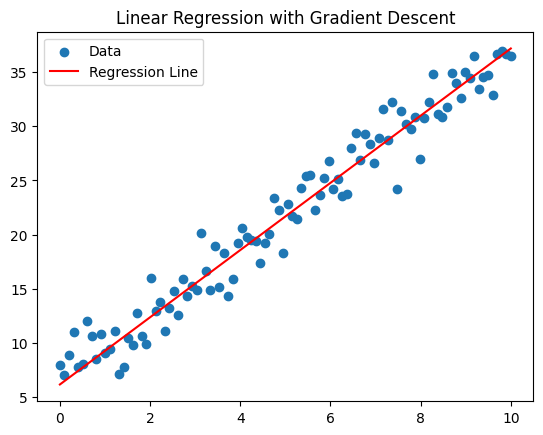

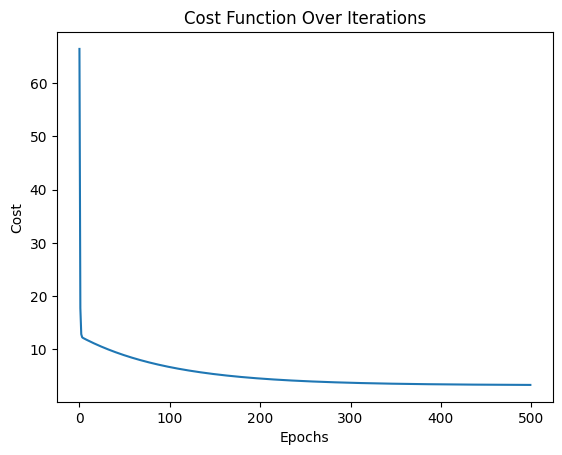

In [ ]:
import numpy as np


# Hypothesis function: y = m*x + b
def hypothesis(x, m, b):
  return m * x + b


# Cost function: Mean Squared Error
def cost_function(x, y, m, b):
  n = len(y)
  predictions = hypothesis(x, m, b)
  cost = (1/n) * np.sum((y - predictions)**2)
  return cost


# Gradient Descent
def gradient_descent(x, y, m_init=0, b_init=0, lr=0.01, epochs=1000):
  m, b = m_init, b_init
  n = len(y)
  costs = []
  for _ in range(epochs):
    y_pred = hypothesis(x, m, b)
    dm = -(2/n) * np.sum(x * (y - y_pred))
    db = -(2/n) * np.sum(y - y_pred)
    m -= lr * dm
    b -= lr * db
    costs.append(cost_function(x, y, m, b))
  return m, b, costs


# Generate synthetic data
np.random.seed(42)
x = np.linspace(0, 10, 100)
y = 3*x + 7 + np.random.randn(100) * 2


# Train model
m, b, costs = gradient_descent(x, y, lr=0.01, epochs=500)
print(f"Final slope (m): {m:.2f}, Intercept (b): {b:.2f}")


# Plot fitted line
plt.scatter(x, y, label="Data")
plt.plot(x, hypothesis(x, m, b), color="red", label="Regression Line")
plt.legend()
plt.title("Linear Regression with Gradient Descent")
plt.show()


# Plot cost over epochs
plt.plot(costs)
plt.title("Cost Function Over Iterations")
plt.xlabel("Epochs")
plt.ylabel("Cost")
plt.show()

## Using scikit-learn

Intercept (b): 6.65, Slope (m): 3.03


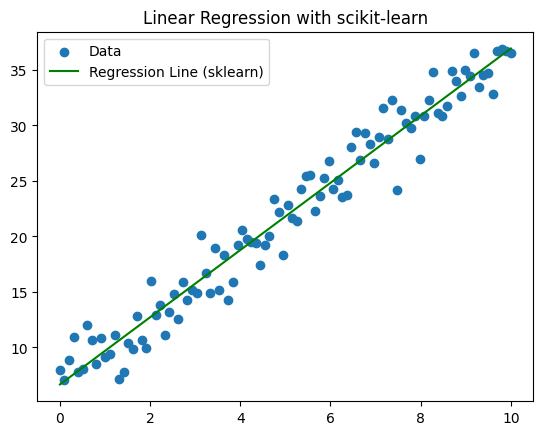

In [ ]:
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

# Reshape x because sklearn expects 2D features
x_reshaped = x.reshape(-1, 1)

# Create and fit sklearn model
model = LinearRegression()
model.fit(x_reshaped, y)

print(f"Intercept (b): {model.intercept_:.2f}, Slope (m): {model.coef_[0]:.2f}")

# Plot data and regression line
plt.scatter(x, y, label="Data")
plt.plot(x, model.predict(x_reshaped), color="green", label="Regression Line (sklearn)")
plt.legend()
plt.title("Linear Regression with scikit-learn")
plt.show()


## 🔍 Different Possible Cost Functions in Linear Regression

In linear regression, the choice of **cost function** determines how errors are penalized.  
Different cost functions can lead to different behaviors, especially when dealing with **outliers**.

## 1. Mean Squared Error (MSE)
$$
J(m, b) = \frac{1}{2n} \sum_{i=1}^n \big( y^{(i)} - (m x^{(i)} + b) \big)^2
$$

- Penalizes **large errors more strongly** (squared term).
- Smooth gradient → works well with gradient descent.


## 2. Mean Absolute Error (MAE)
$$
J(m, b) = \frac{1}{n} \sum_{i=1}^n \big| y^{(i)} - (m x^{(i)} + b) \big|
$$

- Penalizes errors **linearly** (all errors treated equally).
- More **robust to outliers** than MSE.
- Gradient is not smooth at 0 (absolute value "kink").



## 3. Huber Loss
$$
J_\delta(e) =
\begin{cases}
\frac{1}{2} e^2 & \text{if } |e| \leq \delta \\
\delta \big(|e| - \frac{1}{2}\delta \big) & \text{if } |e| > \delta
\end{cases}
$$

Where:
- $ e = y^{(i)} - (m x^{(i)} + b) $ is the prediction error,
- $ \delta > 0 $ is a hyperparameter controlling the transition between quadratic and linear loss.


- Combines the best of **MSE** and **MAE**:
  - Quadratic for small errors (like MSE).
  - Linear for large errors (like MAE).
- More robust to outliers than MSE, smoother than MAE.



✅ Summary:
- **MSE** → sensitive to outliers, smooth optimization.
- **MAE** → robust to outliers, but optimization less smooth.
- **Huber** → compromise between the two.


## Regression Evaluation Metrics

While **loss functions** guide how a model learns during training, **evaluation metrics** tell us **how well the trained model performs on unseen data**.  

### 1. Mean Squared Error (MSE)  
$$
MSE = \frac{1}{n} \sum_{i=1}^n (y^{(i)} - \hat{y}^{(i)})^2
$$  
- Same idea as training loss, but used just for evaluation.  
- Lower values = better fit.  
- Sensitive to outliers.  

### 2. Root Mean Squared Error (RMSE)  
$$
RMSE = \sqrt{MSE}
$$  
- In the **same units as the target variable**.  
- Easier to interpret than MSE.  

### 3. Mean Absolute Error (MAE)  
$$
MAE = \frac{1}{n} \sum_{i=1}^n \big| y^{(i)} - \hat{y}^{(i)} \big|
$$  
- Average absolute deviation.  
- Robust to outliers.  
- Same units as the target variable.  

### 4. Coefficient of Determination ($R^2$ Score)  
$$
R^2 = 1 - \frac{\sum_{i=1}^n (y^{(i)} - \hat{y}^{(i)})^2}{\sum_{i=1}^n (y^{(i)} - \bar{y})^2}
$$  
Where $\bar{y}$ is the mean of observed values.  

- Proportion of variance explained by the model.  
- $R^2 = 1$ → perfect predictions.  
- $R^2 = 0$ → model is no better than predicting the mean.  
- Can be negative if model is worse than the baseline.  

**✅ Summary:**  
- **Loss functions** (MSE, MAE, Huber) → used **during training**.  
- **Evaluation metrics** (MSE, RMSE, MAE, $R^2$) → used **after training** to assess performance.

# **Assignment: Predict House Prices using Linear Regression**

Use a dataset (for example, the **Boston Housing dataset** or **California Housing dataset** from `sklearn.datasets`) to build models that predict house prices.


## Tasks

### 1. Data Exploration & Cleaning
- Load the dataset and explore its structure.
- Handle missing or inconsistent values if present.
- Visualize key relationships between features and the target (price).


### 2. Feature Engineering
- Create meaningful features if needed (e.g., combining or transforming existing features).
- Encode categorical variables appropriately.
- Avoid including features that directly leak the target information.


### 3. Modeling & Training
- Train a **linear regression model** using scikit-learn.
- Optionally, experiment with **other regression algorithms** (Ridge, Lasso, or Gradient Boosting).


### 4. Evaluation
- Evaluate models using appropriate regression metrics:  
  - Mean Squared Error (MSE)  
  - Root Mean Squared Error (RMSE)  
  - Mean Absolute Error (MAE)  
  - R² score
- Visualize predictions versus true values.
- Discuss which features are most important for predicting price.


### 5. Reflection
Answer the following =:
- How well does the linear regression model perform?  
- Are there features that dominate the predictions?  
- Did scaling or feature engineering improve performance?  
- How would you handle non-linear relationships?


✅ Deliverables:
- A **Colab notebook** with:
  - Cleaned and explored dataset
  - Model training code
  - Plots and metrics for evaluation
  - Reflections and answers in Markdown
